# Lab 1, Core B: The DFT as a change of basis
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>

## Completed by:
*   First team member
*   Second team member


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### What this core is about

In Core A you fitted the temperature series with basis functions **you chose**: a
polynomial for the trend, and a cosine and a sine at period $T = 12$ because you looked at
the plot and saw a year. The fit was good because the guess was good.

Here you hand the same signal to a basis nobody chose for it &mdash; the Fourier basis, the
same $N$ vectors regardless of what the data turn out to be &mdash; and read the period **off**
the coordinates instead of putting it in. Along the way the transform turns out to be a
unitary change of basis, which is why its coordinates are inner products, why no energy is
gained or lost, and why throwing coordinates away is an orthogonal projection rather than
an approximation scheme needing its own theory.

Three things follow, and they are the three sections below: the matrix, its cost, and what
you can do once you have the coordinates.

### Marking

**Core B** of Lab 1, worth 2 of the lab's 6 points, awarded at the **oral defence**.
Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of Core A, Extension 3 at the end of this one. Attempt at most one; a second earns nothing.

### Ground rules

* Build the transform yourself. `np.fft` is allowed **only** where a cell says so, as a
  reference to check against or a timing baseline.
* Complex arithmetic throughout. Recall the convention from the notes: the inner product
  on $\mathbb{C}^N$ is $\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^{*}\mathbf{y}$,
  conjugating the **first** argument, and $U$ is unitary when $U^{*}U = I$.
* In `numpy`, `A.conj().T` is the adjoint. `A.T` alone is a common and silent bug here.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from time import perf_counter


In [ ]:
# COMMENT TO REVIEWERS
# Change it if you need it

# file_name = '/content/drive/MyDrive/la_lab1/land-temp-1850-2015.csv'
file_name = './land-temp-1850-2015.csv'

In [ ]:
temp_data = pd.read_csv(file_name)
temp_data["date"] = pd.to_datetime(temp_data["date"])

y = temp_data["avg_temp"].to_numpy()
N = y.shape[0]
print(f"N = {N} monthly readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")

# Same series as Core A: Berkeley Earth global land average, 1850-2015.
# See Core A section 0 for what it is and why it starts in 1850.


N = 1992 monthly readings, 1850-01 to 2015-12


---
## 1. The Fourier matrix, and what makes it a basis

Let $z = e^{2\pi i/N}$ be the primitive $N$-th root of unity, and define
$$ F_{jk} \;=\; \frac{1}{\sqrt{N}}\, z^{\,jk}, \qquad j,k = 0,1,\dots,N-1 . $$
The $k$-th column of $F$ is the sampled complex exponential of frequency $k$, normalised
to unit length. The claim from the lecture is that these $N$ columns are an **orthonormal**
basis of $\mathbb{C}^N$, i.e. that $F$ is unitary. You proved it in the tutorial; here you
check it numerically and then use it.


In [ ]:
n = 4

# np.arange(n)- gives numbers from 0 to n-1

exponents = np.outer(np.arange(n), np.arange(n))

print(exponents)

print(2**exponents / np.sqrt(n))

[[0 0 0 0]
 [0 1 2 3]
 [0 2 4 6]
 [0 3 6 9]]
[[  0.5   0.5   0.5   0.5]
 [  0.5   1.    2.    4. ]
 [  0.5   2.    8.   32. ]
 [  0.5   4.   32.  256. ]]


In [ ]:
def fourier_matrix(n: int) -> np.ndarray:
    """The n x n unitary Fourier matrix F with F[j,k] = z**(j*k)/sqrt(n).

    Build it with numpy broadcasting, not a double Python loop.
    Hint: np.outer(np.arange(n), np.arange(n)) gives the matrix of exponents.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    exponents = np.outer(np.arange(n), np.arange(n))
    # i == 1j
    z = np.e**(2 * np.pi * 1j / n)
    F = z ** exponents / np.sqrt(n)
    # ========== YOUR CODE ENDS HERE ========== #
    return F


def test_fourier_matrix():
    F = fourier_matrix(4)
    assert F.shape == (4, 4) and np.iscomplexobj(F)
    assert np.allclose(F[:, 0], 0.5), "column 0 should be constant 1/sqrt(4)"
    assert np.allclose(F.conj().T @ F, np.eye(4), atol=1e-12), "F is not unitary"
    print("TEST 1: SUCCESS")

test_fourier_matrix()


TEST 1: SUCCESS


In [ ]:
F = fourier_matrix(4)
print(F[1])

[ 5.00000000e-01+0.000000e+00j  3.06161700e-17+5.000000e-01j
 -5.00000000e-01+6.123234e-17j -9.18485099e-17-5.000000e-01j]


In [ ]:
np.e**(3 * np.pi * 1j * 2 / 4)/2


(-9.184850993605148e-17-0.5j)

### **1.1** Unitary, and what it buys

For $N = 8$, compute and report:

1. $\|F^{*}F - I\|$. State what magnitude counts as zero here and why it is not exactly zero.
2. $\operatorname{cond}(F)$. Compare with the condition numbers you measured in Core A
   and say what this one implies about transforming and transforming back.
3. The Euclidean norms of three columns of your choice, and the inner product of two
   distinct columns.

Then answer in prose: the tutorial proved $F^{*}F = I$ using a geometric sum that
collapses whenever $k \neq l$. Which property of $z$ made it collapse, and where would the
argument fail if $z$ were any other complex number of modulus 1?


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
n = 8
F = fourier_matrix(n)

difference_with_I = (F.conj().T @ F) - np.eye(n)
frobenius_norm = np.linalg.norm(difference_with_I)
machine_epsilone = np.finfo(float).eps
combined_eps = n**2 * machine_epsilone
is_combined_eps_bigger_then_norm = combined_eps > frobenius_norm

print(f'Frobenius norm of a F * F - I = {frobenius_norm}', end = '\n---\n')

print(f'Is {n**2} * eps > then norm? {is_combined_eps_bigger_then_norm}', end = '\n---\n')

f_cond = np.linalg.cond(F)

print(f'Conditional number of F = {f_cond}', end = '\n---\n')

col_2 = F[:, 2]
col_4 = F[:, 4]
col_5 = F[:, 5]

norm_col_2 = np.linalg.norm(col_2)
norm_col_4 = np.linalg.norm(col_4)
norm_col_5 = np.linalg.norm(col_5)
inner_prod_of_2_and_5 = np.dot(col_2, col_5)

print(f'Norm of column 2 = {norm_col_2}')
print(f'Norm of column 4 = {norm_col_4}')
print(f'Norm of column 5 = {norm_col_5}')
print(f'Inner product of column 2 and 5 = {inner_prod_of_2_and_5}')
# ========== YOUR CODE ENDS HERE ========== #


Frobenius norm of a F * F - I = 2.2508651239978283e-15
---
Is 64 * eps > then norm? True
---
Conditional number of F = 1.0000000000000004
---
Norm of column 2 = 0.9999999999999999
Norm of column 4 = 0.9999999999999999
Norm of column 5 = 0.9999999999999999
Inner product of column 2 and 5 = (9.43281047001103e-16+3.899728465621185e-16j)


---

> Add blockquote


\### **YOUR ANSWER HERE** \###

---

1. The magnitude of difference of conj(F)^T @ F and I is 2.2508651239978283e-15 which does count as zero here cause it's smaller then combined errors of matrix multiplication of 8*8 matrixes which we approximate by `N**2 * epsilone` because epsilone is an error that is inevidable at our precision and norm has `N**2 elements`.
This gives us a fact that when we transform vector usign F and then reverse the transofrmation- we get the exact same vector cause we didn't lose the info.
2. **GET VALUE FROM BLOCK A FOR COMPARISON**

The conditionla number is 1+4*10^(-16) which is NOT 1 in double precision, which means we can our transofrmation back and forth will will mess up the original value.

3. The norms are shifted from 1 by 1*10^(-16) which makes them same as 1
  1. Norm of column 2 = 0.9999999999999999
  2. Norm of column 4 = 0.9999999999999999
  3. Norm of column 5 = 0.9999999999999999
  4. Inner product of column 2 and 5 = 9.43281047001103e-16+3.899728465621185e-16j

In [ ]:
print(0.9999999999999999)
print(1.0000000000000004)
print(1 - 2.2508651239978283e-15)
print(1 - 0.0000000000000022 == 1 - 2.2508651239978283e-15)

0.9999999999999999
1.0000000000000004
0.9999999999999978
True


### **1.2** Coordinates are inner products

Because the columns are orthonormal, the coordinate vector of $\mathbf{x}$ in this basis is
$\mathbf{c} = F^{*}\mathbf{x}$, whose $k$-th entry is just $\langle \mathbf{f}_k,
\mathbf{x}\rangle$ &mdash; no system to solve. Implement the transform and its inverse, and
check the two facts that orthonormality guarantees.


In [ ]:
def dft(x: np.ndarray) -> np.ndarray:
    """Coordinates of x in the Fourier basis: c = F^* x. Build F and apply it."""
    # ========= YOUR CODE STARTS HERE ========= #
    N = x.size
    F = fourier_matrix(N)

    c = F @ x
    # ========== YOUR CODE ENDS HERE ========== #
    return c


def idft(c: np.ndarray) -> np.ndarray:
    """Back from coordinates to the signal. One line, and no matrix inverse:
    F is unitary, so you already know what F^{-1} is.

    NOTE: this returns a COMPLEX array, always. Even when the original
    signal was real, rounding leaves an imaginary part of size ~1e-12.
    Take .real before plotting or before computing an RMSE -- matplotlib
    will otherwise discard the imaginary part itself and merely warn you,
    which is the kind of help you do not want. Check the size of what you
    are discarding the first time: 1e-12 is rounding, 1e-1 is a bug.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    N = c.size
    F = fourier_matrix(N)

    x = F.conj().T @ c
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def test_dft():
    rng = np.random.default_rng(1)
    x = rng.standard_normal(16)
    c = dft(x)
    assert np.allclose(idft(c), x, atol=1e-12), "round trip failed"
    assert np.isclose(np.linalg.norm(c), np.linalg.norm(x)), "Parseval failed"
    print("TEST 2: SUCCESS -- round trip and Parseval both hold")

test_dft()


TEST 2: SUCCESS -- round trip and Parseval both hold


### **1.3** Parseval, and why it is not a coincidence

You have just checked $\|F^{*}\mathbf{x}\| = \|\mathbf{x}\|$ on a random vector. Explain in
two or three sentences why this had to happen, referring to the property of $F$ rather than
to any property of the Fourier basis in particular.

Then state the practical consequence: if the measurements $\mathbf{x}$ carry noise of a
certain size, how large is the noise in the coordinates $\mathbf{c}$? Contrast with what a
**non**-orthogonal change of basis would do to it.

---
\### **YOUR ANSWER HERE** \###

Previously we checked that `F` is indeed unitary, has condtional number 0. This means that when we apply `F`, our x didn't change in size, e.g. didn't contribute error to `x`, so when we reverse the tranformation we get the same vector.

`c` will carry only the noise that is already present in `x`, which is the epsilone of our system.

In case of conditional number being bigger, the noise would be mutiplied by conditional number. So when going from `x` to `c` the noise gets multiplied by conditional number and then once again going form `c` to `x`, so we have much more noise and corrupted value of x.

---


---
## 2. Reading the period off the data

Now transform the temperature series. Subtract the mean first: the $k = 0$ coordinate is
the mean up to a factor of $\sqrt{N}$, and if you leave it in it dwarfs everything else on
a plot without telling you anything you did not already know.


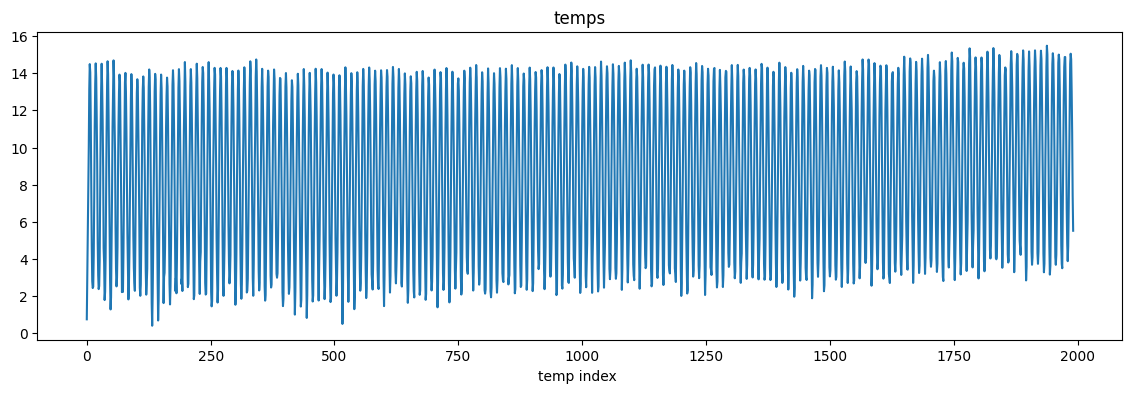

In [ ]:
# Just to check actual data
plt.figure(figsize=(14, 4))
plt.plot(y)
plt.xlabel("temp index ");
plt.title("temps");
plt.show()

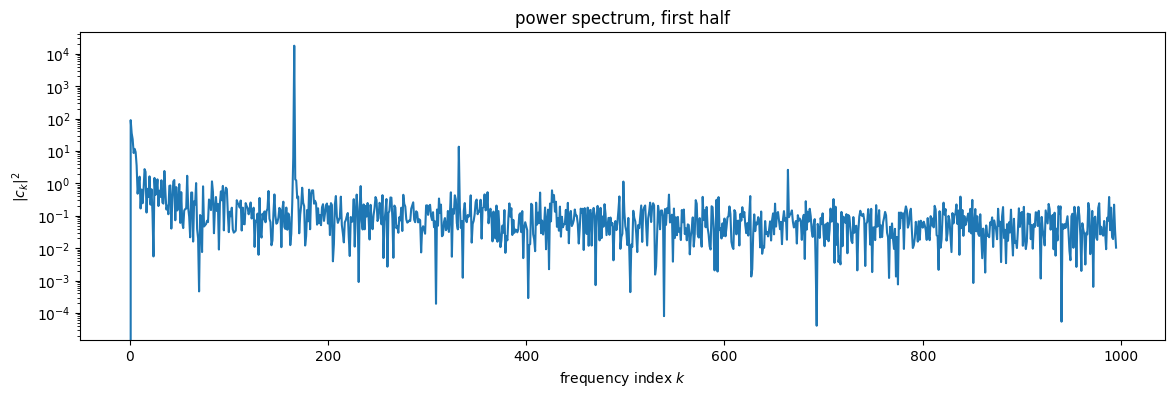

In [ ]:
x = y - y.mean()

# ========= YOUR CODE STARTS HERE ========= #
c = dft(x)                     # coordinates of x in the Fourier basis
power = abs(c) ** 2                 # |c_k|^2, the energy carried by coordinate k
# ========== YOUR CODE ENDS HERE ========== #

plt.figure(figsize=(14, 4))
plt.semilogy(power[:N // 2])
plt.xlabel("frequency index $k$"); plt.ylabel("$|c_k|^2$")
plt.title("power spectrum, first half"); plt.show()


### **2.1** Find the peak and interpret it

1. Report the index $k^{\star}$ of the largest $|c_k|^2$ for $1 \le k < N/2$.
2. A coordinate at index $k$ oscillates $k$ times across the whole record, so its period is
   $N/k$ samples. Convert $k^{\star}$ to a period in months. Is it what you expected?
3. Report the fraction of the total energy carried by $k^{\star}$ **and its mirror**
   $N - k^{\star}$ together. (Why must you count both? Your signal is real; what does that
   force on $\mathbf{c}$?)

   *Hint: this is not in the notes, so derive it. Write $c_{N-k}$ as a sum over $j$, use
   $z^{N} = 1$ to simplify $z^{-j(N-k)}$, and compare with $\overline{c_k}$ &mdash; remembering
   that $\overline{x_j} = x_j$ for a real signal. Two lines. You will need the result in
   4.0.*
4. $N = 1992 = 12 \times 166$. Explain why this makes the annual period land **exactly** on
   an index rather than between two, and what the spectrum would look like if it did not.


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
index_of_peak = np.argmax(power[:N // 2])

print(f'Index of the peak {index_of_peak}')

# Number of months divided by the number coordinate of the peak
period = N / index_of_peak;

print(f'{period = }')

all_energy = np.sum(power ** 2)
energy_at_k_star = power[index_of_peak] ** 2
energy_at_k_star_mirror = power[N - index_of_peak] ** 2

fraction_by_k_star = energy_at_k_star / all_energy
fraction_by_k_star_mirror = energy_at_k_star_mirror /  all_energy

print(f'Fraction of power in k* = \n{fraction_by_k_star}')
print(f'Fraction of power in mirror of k* = \n{fraction_by_k_star_mirror}')
print(f'Sum of the fractions = \n{fraction_by_k_star + fraction_by_k_star_mirror}')

# sampled_by_month = N // 12
# value_sampled_by_month = power[sampled_by_month]

# print(f'index of sampling by month = {sampled_by_month}')
# print(f'value of sampling by month = {value_sampled_by_month}')

# energy_in_k_star = power[:N // 2][index_of_peak]
# energy_in_N_minus_k_star = power[:N][N - index_of_peak]

# print(energy_in_k_star)
# print(energy_in_N_minus_k_star)
# print(f'their dif = {energy_in_k_star - energy_in_N_minus_k_star}')
# ========== YOUR CODE ENDS HERE ========== #


Index of the peak 166
period = np.float64(12.0)
Fraction of power in k* = 
0.4999834476395424
Fraction of power in mirror of k* = 
0.4999834476826374
Sum of the fractions = 
0.9999668953221799


---
\### **YOUR ANSWER HERE** \###

---

1. $k^{\star}$ is 166 which equals to the amount of years in our dataset
2. Period in month got converted to 12, which is intuitive since we would expect a yearly seasonal pattern
3. The sum of seasonal frequencies give almost 1, so they carry almost all the power
4. The reason index is exactly 166 cause that's a number that would result period to be 12, meaning a full year. If there were no inter result of devision -> the energy would be destributed between near values, making it harder to spot the seasonality

### **2.2** The bridge back to Core A

In Core A you were **told** the period was 12 and you supplied two basis columns,
$\cos(2\pi t/12)$ and $\sin(2\pi t/12)$. Here you were told nothing and the data produced
$k^{\star}$.

1. Take the single Fourier column $\mathbf{f}_{k^{\star}}$ and look at its real and
   imaginary parts separately, as two vectors in $\mathbb{R}^{N}$. Plot the first 36
   entries of each. Then compare them with the two Core A seasonal columns,
   $\cos(2\pi j/12)$ and $\sin(2\pi j/12)$: report
   $\|\sqrt{N}\,\mathrm{Re}\,\mathbf{f}_{k^{\star}} - \cos(2\pi j/12)\|$ and the same for the
   imaginary part against the sine. What do you get, and why is it that rather than merely
   something small?

   *Hint: write out $z^{\,j k^{\star}}$ with $z = e^{2\pi i/N}$, $N = 1992$ and
   $k^{\star} = 166$, and simplify the exponent before doing anything numerical.*
2. So the two approaches found the same thing. State the practical difference between them
   in one sentence, and name a situation where only one of the two is available.
3. Look at $k = 2k^{\star}$ and $k = 3k^{\star}$ in the spectrum. What are those, and what
   does their size tell you about the *shape* of the annual cycle?


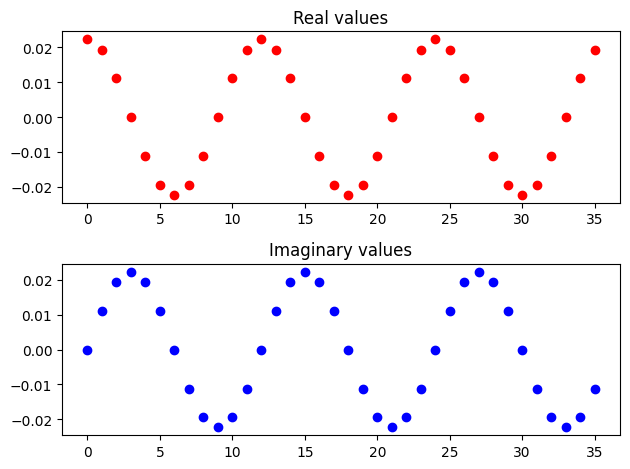

Norm of real value minus the cos: 
1.860555422996482e-13
Norm of imaginary value minus the sin: 
1.9409217427147731e-13
first harmonic val = 13.57082751970212, fraction of seasonal 0.0007644514873695258%
second harmonic val = 1.1390692455003748, fraction of seasonal 6.416433910721151e-05%


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
F = fourier_matrix(N)
ENTRIES_LIMIT = 36
x_axis = np.arange(ENTRIES_LIMIT)
column_k_star = F[index_of_peak][:ENTRIES_LIMIT]
column_k_star_real = np.real(column_k_star)
column_k_star_imag = np.imag(column_k_star)
fig, (real_plot, imag_plot) = plt.subplots(2, 1)

real_plot.scatter(x_axis, column_k_star_real, color = 'red')
imag_plot.scatter(x_axis, column_k_star_imag, color = 'blue')
real_plot.set_title('Real values')
imag_plot.set_title('Imaginary values')

plt.tight_layout()
plt.show()

cos_array = np.cos(2 * np.pi * x_axis / 12)
sin_array = np.sin(2 * np.pi * x_axis / 12)
real_dif = np.sqrt(N) * column_k_star_real - cos_array
imag_dif = np.sqrt(N) * column_k_star_imag - sin_array
norm_of_real_dif = np.linalg.norm(real_dif)
norm_of_imag_dif = np.linalg.norm(imag_dif)


print(f'Norm of real value minus the cos: \n{norm_of_real_dif}')
print(f'Norm of imaginary value minus the sin: \n{norm_of_imag_dif}')

val_of_seasonal = power[index_of_peak]
val_of_first_harmonic = power[2 * index_of_peak]
val_of_second_harmonic = power[3 * index_of_peak]

print(f'first harmonic val = {val_of_first_harmonic}, fraction of seasonal {val_of_first_harmonic / val_of_seasonal}%')
print(f'second harmonic val = {val_of_second_harmonic}, fraction of seasonal {val_of_second_harmonic / val_of_seasonal}%')

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###

---
1. The comparison of this value with cos and sin are exactly 0 (we don't see zeros because of precisions issues)
3. These values are called harmonics and they tell us about asymetry of the seasonal component. Our values are tiny, which says us that weather change follows seasonality smoothly

---
## 3. The cost, and the algorithm that removes it

Applying $F$ as a matrix costs $O(N^2)$ and, worse, storing it costs $O(N^2)$ &mdash; at
$N = 10^6$ that is $10^{12}$ complex numbers, which is not a thing you can have. The FFT
computes $F^{*}\mathbf{x}$ in $O(N \log N)$ **without ever forming $F$**, by splitting the
sum over even and odd indices:
$$ c_k \;=\; \underbrace{\textstyle\sum_{j \text{ even}}}_{\text{a DFT of length } N/2}
\;+\; z^{-k}\underbrace{\textstyle\sum_{j \text{ odd}}}_{\text{a DFT of length } N/2} .$$


### **3.1** Why not on this series?

Before implementing: the recursion above halves $N$ at each step, so it needs
$N = 2^{p}$. Our series has $N = 1992 = 2^3 \cdot 3 \cdot 83$.

Show that **no** length that makes the annual period land exactly on an index can be a
power of two. (One line: what must $N$ be divisible by, and what is $12$ made of?)

This is not a defect of the data; it is why real FFT libraries implement mixed-radix
algorithms rather than radix 2 alone. Sections 3.2-3.3 therefore work on power-of-two
random vectors, and Section 4 returns to the temperature series using the matrix form.

---
\### **YOUR ANSWER HERE** \###

To get index of anual period we devide by two and the result of devision to be a whole number. We know that N has not be divisible by 2 and can be represented as $N = 2^{p} * a$

So

$2^{p} * a / 12 = 2^{p} * a / (2^2 * 3) = 2^{p - 2} * a / 3$

To get a whole number, `a` has to be divisible by 3, making it impossible for `N` to be a power of 2

---


In [ ]:
# # First we pad the size of x to be a power of 2, to be more efficient
# log_of_2 = np.log2(n)
# ceil_val = np.ceil(log_of_2)
# # How many zeros we need to get to the next power of 2
# number_of_paddings = ceil_val - n
# padded_x = np.pad(x, (0, number_of_paddings), mode='constant')
# paddded_n = padded_x.shape[0]

In [ ]:
arr = np.array([1,2,3,4,5,6])


even_indecies = arr[0::2]
odd_indecies = arr[1::2]

print(even_indecies)
print(odd_indecies)

[1 3 5]
[2 4 6]


In [ ]:
def fft_recursive(x: np.ndarray) -> np.ndarray:
    """Radix-2 Cooley-Tukey, returning the same thing as dft(x).

    Requires len(x) to be a power of two. Base case: length 1.

    Careful with the normalisation. Our dft() divides by sqrt(N) once, at
    the top level; a recursive call on length N/2 would divide by
    sqrt(N/2). Decide where the factor goes and be consistent -- the test
    below will catch you if you are not.
    """
    n = x.shape[0]
    assert n & (n - 1) == 0, "length must be a power of two"
    # ========= YOUR CODE STARTS HERE ========= #
    def _fft(x):
      nn = x.shape[0]

      if nn == 1:
        return x

      k = np.arange(nn//2)
      z = np.e**(2 * np.pi * 1j / nn)
      twidle_factors = z**(k)
      even_fft = _fft(x[0::2])
      odd_fft = _fft(x[1::2])
      sum_of_parts = even_fft + twidle_factors * odd_fft
      dif_of_parts = even_fft - twidle_factors * odd_fft
      combined_parts = np.concatenate([sum_of_parts, dif_of_parts])

      return combined_parts
    return _fft(x) / np.sqrt(n)


    # ========== YOUR CODE ENDS HERE ========== #


def test_fft():
    rng = np.random.default_rng(2)
    for n in (1, 2, 8, 64):
        v = rng.standard_normal(n) + 1j * rng.standard_normal(n)
        assert np.allclose(fft_recursive(v), dft(v), atol=1e-10), f"mismatch at n={n}"
    print("TEST 3: SUCCESS -- recursion agrees with the matrix form")

test_fft()


TEST 3: SUCCESS -- recursion agrees with the matrix form


### **3.2** Measure the two costs

Time your matrix `dft` and your `fft_recursive` on random vectors of length
$2^{p}$ for $p = 4, \dots, 12$, and plot both on log-log axes. Add `np.fft.fft` as a third
line.

1. Fit a straight line to each log-log curve and report the slopes. What slope does theory
   predict for each of the three?
2. At which $N$ does your recursion overtake your matrix version? Is it where you expected,
   and if not, what is the recursion paying that the flop count does not show?
3. `np.fft.fft` is also $O(N\log N)$, and it will still beat your recursion by a wide
   margin. Name two reasons that have nothing to do with the asymptotics.


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
import time

rng = np.random.default_rng(seed=42)

powers = np.arange(4,13)
sizes = 2 ** powers
random_vectors_of_sizes = [rng.random(i) for i in sizes]


def run_method_and_record_time(method, vectors):
  execution_times = np.array([])

  for vector in vectors:
    start_time = time.perf_counter()

    method(vector)

    elapsed_time = time.perf_counter() - start_time

    execution_times = np.append(execution_times, elapsed_time)

  return execution_times


execution_times_for_dft = run_method_and_record_time(dft, random_vectors_of_sizes)
execution_times_for_recursive = run_method_and_record_time(fft_recursive, random_vectors_of_sizes)
execution_times_for_fft = run_method_and_record_time(np.fft.fft, random_vectors_of_sizes)


# ========== YOUR CODE ENDS HERE ========== #


In [ ]:
execution_times_for_dft

array([1.91641000e-04, 2.51258000e-03, 5.77158500e-03, 1.98874170e-02,
       6.17422870e-02, 1.50209107e-01, 3.78113584e-01, 1.35271466e+00,
       5.61083089e+00])

In [ ]:
import plotly.graph_objects as go
# pip install plotly

fig = go.Figure()
fig.add_trace(go.Scatter(x=sizes, y=execution_times_for_dft, name="DFT", line=dict(color="red")))
fig.add_trace(go.Scatter(x=sizes, y=execution_times_for_recursive, name="Recursive FFT", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=sizes, y=execution_times_for_fft, name="np.fft.fft", line=dict(color="green")))

fig.update_xaxes(type="log", title="Array size")
fig.update_yaxes(type="log", title="Time per call (s)")
fig.show()

---
\### **YOUR ANSWER HERE** \###

---
1. The theory predicts that DFT will be doing power(2) many flops for each increase of the amount of data (e.g. for 2 elements `2^2` operations, for 3 elements `2^3`, for 4 `2^4`), meaning there will be exponential growth.

While for recursive and FFT having complexity O(n*log(n)) giving logarithmic slope, result will be getting bigger only by a small part. At first iterations the change is not drammatic but it gets there quickly.

2. Recursive algorithm overtakes at n = 64. I was expecting it happen sooner, at size `4` cause `4^2 > 4 * log(4)`. I think it happens so because of variable allocations for each recursive run, high optimisation of matrix multiplication in numpy (that helps DFT go faster) and overhead caused by functions creation for recursion.

3. np.fft.fft absolutely beats recursive implememnation cause 1) it's implemented on C with a lot of optimisations 2) avoid recursion

### **3.3** Matrix-free, and why it matters beyond speed

Your `dft` builds an $N \times N$ matrix; `fft_recursive` builds nothing. For
$N = 2^{20}$, state the memory each would need, in bytes, for complex128.

Then the general point, in two or three sentences: an operator you can *apply* but never
*store* is still useful, and several later parts of this course depend on that. Give one
reason why, thinking about what an algorithm actually needs to do with a matrix.

---
\### **YOUR ANSWER HERE** \###

Each complex number takes 32 bytes
```
import sys

x = 3.14+2j
print(sys.getsizeof(x))
>>> 32
```

For N = 2^20 we have matrix of size N*N having 2^40 elements giving
`32*2^40 = 35184372088832` bytes, which is >35 gigabites:)


An operator you can apply but cannot store is useful because the result of it's application can be useful and much smaller

---


---
## 4. Keeping the large coordinates

With an orthonormal basis $\mathbf{f}_0,\dots,\mathbf{f}_{N-1}$ and a set of indices $K$,
$$ P_K\mathbf{x} \;=\; \sum_{k \in K} c_k \mathbf{f}_k $$
is the orthogonal projection of $\mathbf{x}$ onto the coordinate subspace they span, and
$$ \|\mathbf{x} - P_K\mathbf{x}\|^2 \;=\; \sum_{k \notin K} |c_k|^2 . $$
The error is exactly the energy you discarded. Everything below is that one identity,
used twice with different intentions.


In [ ]:
def keep_largest(c: np.ndarray, m: int) -> np.ndarray:
    """Zero all but the m coordinates of largest modulus."""
    # ========= YOUR CODE STARTS HERE ========= #
    idx = np.argsort(np.abs(c))[-m:]

    out = np.zeros_like(c)
    out[idx] = c[idx]
    # ========== YOUR CODE ENDS HERE ========== #
    return out


### **4.0** An experiment before you use it

Reconstruct with `m = 2`, then with `m = 3`, and in each case report
`np.abs(reconstruction.imag).max()`.

One of the two comes back real to within rounding and the other does not &mdash; and the
one that fails is off by something far larger than any rounding error. Explain it, using
your answer to 2.1(3). Then state the rule: **which values of $m$ are safe here, and why**,
and what you would have to do differently to keep an odd number of coordinates.

*(This is not a detour. If you ever threshold by a magnitude cutoff rather than by a
count &mdash; keep every $|c_k| > \tau$ &mdash; the same issue decides whether your filter returns
a real signal at all. Everything below uses even $m$ for exactly this reason.)*


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
keeping_two = keep_largest(c, 2)
keeping_tree = keep_largest(c, 3)
inverse_1 = idft(keeping_two)
inverse_2 = idft(keeping_tree)

print('Max value of absolute imag values in frequncy domain ')
print(np.abs(keeping_two.imag).max())
print(np.abs(keeping_tree.imag).max())

print('Max value of absolute imag time domain')
print(np.abs(inverse_1.imag).max())
print(np.abs(inverse_2.imag).max())
# ========== YOUR CODE ENDS HERE ========== #


Max value of absolute imag values in frequncy domain 
10.61202855887507
10.61202855887507
Max value of absolute imag time domain
1.943432081930041e-10
0.2121540694755588


---
\### **YOUR ANSWER HERE** \###

---

so for m = 2, the max imag valus is 0. This is because as we seen in block 2, the two biggest values are seasonality pick and its mirror(which is also a conjugate), removing both of them we removed the coresponding pair of imaginary numbers.

but when we remove one additional number without removing it's pair- we have a leftover imaginary number


### **4.1** Verify the identity, then use it

1. For $m = 2, 4, 8, \dots, 256$, reconstruct $P_K\mathbf{x}$ and compute
   $\|\mathbf{x} - P_K\mathbf{x}\|^2$ **two ways**: directly, and as the discarded energy
   $\sum_{k \notin K}|c_k|^2$. Confirm they agree.
2. Plot the fraction of energy retained against $m$. How many coordinates out of
   $N = 1992$ are needed for 98% of the energy?
3. Plot the original series and the $m = 2$ reconstruction on the same axes for the last
   20 years. What has been kept and what has been lost?


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
powers = np.arange(1,9)
m_array = 2 ** powers

kept_values = [keep_largest(c, m) for m in m_array]
P_K_xs = [idft(vector) for vector in kept_values]
norms = [np.linalg.norm(x - P_K_x)**2 for P_K_x in P_K_xs]

total_energy = np.sum(np.abs(c)**2)
discarded_energy = [(total_energy - np.sum(np.abs(k)**2)) for k in kept_values]
fractions_discarded = [(np.abs(k) / total_energy) for k in discarded_energy]
fractions_retained = [1 - frac_discarded for frac_discarded in fractions_discarded]
# ========== YOUR CODE ENDS HERE ========== #


In [ ]:
print(norms)
print(discarded_energy)
print(np.allclose(norms, discarded_energy))

[np.float64(681.3053890627795), np.float64(501.9877386581841), np.float64(385.17549061333443), np.float64(298.8770306599961), np.float64(252.21779976854418), np.float64(215.24222255547647), np.float64(176.81599689823418), np.float64(135.00278695142032)]
[np.float64(681.3053890590527), np.float64(501.9877386492808), np.float64(385.1754906001879), np.float64(298.87703064389643), np.float64(252.21779976187827), np.float64(215.24222255512723), np.float64(176.8159968976688), np.float64(135.00278695277666)]
True


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=m_array, y=fractions_retained, name="Energy left with M", line=dict(color="red")))

fig.update_xaxes(type="log", title="Number of not null coeficients")
fig.update_yaxes(type="log", title="Fraction of power")
fig.show()

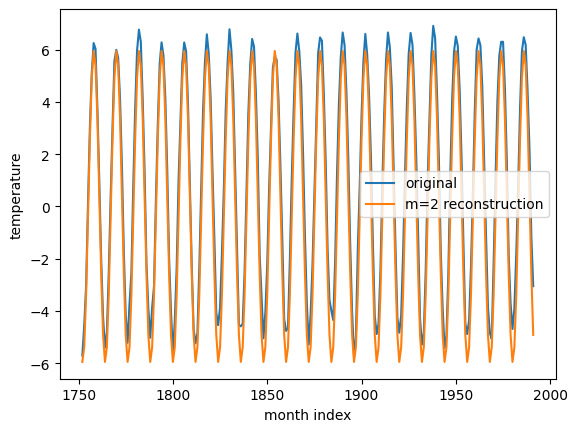

In [ ]:
twenty_years_in_month = 20 * 12
m2_reconstruction = P_K_xs[0].real

months = np.arange(len(x))
last_20_years_mask = months[-twenty_years_in_month:]

plt.plot(last_20_years_mask, x[-twenty_years_in_month:], label="original")
plt.plot(last_20_years_mask, m2_reconstruction[-twenty_years_in_month:], label="m=2 reconstruction")
plt.xlabel("month index")
plt.ylabel("temperature")
plt.legend()
plt.show()

---
\### **YOUR ANSWER HERE** \###

1. By doing np.allclose and getting true, we showed that they agree
2. We can see that m=2 is enough to get almost all power= 98%. This agrees with our observations from block 2
3. The shape and rate are preserved, but waves are identical, because we lost nuances that are not covered by seaonality.

---


### **4.2** Compressible in this basis, or compressible?

Your energy curve is close to flat after a handful of coordinates. Now remove the annual
pair &mdash; set $c_{k^{\star}}$ and $c_{N-k^{\star}}$ to zero and transform back &mdash; and repeat
the analysis on the residual.

1. How many coordinates does the *residual* need for 98% of its energy? Compare with your
   answer for the full series.
2. So: is this signal compressible, or is one component of it compressible? Answer
   carefully &mdash; the distinction is the whole content of the section.
3. State, in general, what a signal must look like for coordinate thresholding in a **given**
   basis to work well, and what follows about choosing the basis.


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #
def remove_largest(c: np.ndarray, m: int) -> np.ndarray:
    """Zero m coordinates of largest modulus."""
    out = c.copy()
    m = min(max(int(m), 0), c.size)

    if m > 0:
        idx = np.argpartition(np.abs(c), -m)[-m:]
        out[idx] = 0

    return out

residual_std = 0

c_residual = remove_largest(c, 2)
residual_std = c_residual.std()

powers = np.arange(1,12)
m_array = 2 ** powers

kept_values = [keep_largest(c_residual, m) for m in m_array]
P_K_xs = [idft(vector) for vector in kept_values]
norms = [np.linalg.norm(x - P_K_x)**2 for P_K_x in P_K_xs]

total_energy = np.sum(np.abs(c_residual)**2)
discarded_energy = [(total_energy - np.sum(np.abs(k)**2)) for k in kept_values]
fractions_discarded = [(np.abs(k) / total_energy) for k in discarded_energy]
fractions_retained = [1 - frac_discarded for frac_discarded in fractions_discarded]

print(f'Does results align {np.allclose(norms, discarded_energy)}')

fig = go.Figure()
fig.add_trace(go.Scatter(x=m_array, y=fractions_retained, name="Energy left with M", line=dict(color="red")))

fig.update_xaxes(type="log", title="Number of not null coeficients")
fig.update_yaxes(type="log", title="Fraction of power")
fig.show()

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###

1. Residual need 256 coordinates to get 80% of the power. I think this shows us that there is no stong frequency that contributes a lot, like seasonality did in original signal
2. This shows us that original signal is VERY highly compressible but only by one component, so in this question I would say that the component is compressible in the original signal. But from residuals that contain all of the data synoptics will probably want to analyse, we see that it's not really compressible. We need a lot of component get enough of the signal's power.
3.
*   Signal must have some small number of elements with a majority of the power
relative to other points to be suitable for coordinate thresholding. The function slope of number of points to the power kind of looks like a logarithmic slope, with a fast rise at first and then increasing slowly
*   In our basis the seasonality can be represented very well, cause seaonality follows a sin function that is encapsulated in Fourier basis, but for example trend can't be represented well in it, cause it is slow rising line, to represent in well we would need a polynomial basis. In a basis that can capture it, the signal would be compressible. So in general to achieve compresibility we also need to choose an appropriate basis that can matches the signal
---


### **4.3** The same operation, called denoising

Corrupt the series with noise: `y_noisy = y + sigma * rng.standard_normal(N)` with
`sigma = 2.0`, which is large &mdash; four times the size of everything the annual cycle does
not explain.

1. Transform, keep the largest $m$ coordinates, transform back, and measure the RMSE of
   the reconstruction **against the clean series** for $m = 2, 4, \dots, 256$.
2. Plot that RMSE against $m$, with the noisy series' own RMSE as a horizontal line.
   The curve is not monotone. Find the $m$ that minimises it.
3. Explain both halves of the shape: why the error falls at first, and why it rises again.
   What is being added back as $m$ grows?
4. Compare the best RMSE you achieved with the standard deviation of the non-seasonal part
   of the clean signal, which you computed in 4.2. Why can no choice of $m$ do much better
   than that number?
5. You have used exactly the operation from 4.1, with the same code. What changed?


In [ ]:
rng = np.random.default_rng(0)
sigma = 2.0
y_noisy = y + sigma * rng.standard_normal(N)
y_noisy_mean = y_noisy.mean()

# Subtract the mean before transforming, and add it back after, exactly as
# you did in section 2. If you leave it in, coordinate k=0 is the largest
# of all and spends one of your m slots re-learning the average -- which
# makes the m=2 reconstruction look far worse than it is.

# ========= YOUR CODE STARTS HERE ========= #
def get_rmse(predicted, actual):
  return np.sqrt(np.mean((predicted - actual) ** 2))

y_noisy_minus_mean = y_noisy - y_noisy_mean

noisy_c = np.fft.fft(y_noisy_minus_mean)
clear_c = np.fft.fft(y)

powers = np.arange(1,9)
m_array = 2 ** powers

kept_values_noisy = [keep_largest(noisy_c, m) for m in m_array]

transformed_back_noisy = [np.fft.ifft(signal).real + y_noisy_mean for signal in kept_values_noisy]


rmse_s = [get_rmse(noisy, y) for noisy in transformed_back_noisy]
noisy_rmse = get_rmse(y_noisy, y)

print(rmse_s)

fig = go.Figure()
fig.add_trace(go.Scatter(x=m_array, y=rmse_s, name="RMSE with different amount of coordinates m", line=dict(color="red")))

fig.add_hline(
    y=noisy_rmse,
    line=dict(color="gray", dash="dash"),
    annotation_text=f"RMSE line = {noisy_rmse:.2f}",
    annotation_position="top right"
)

fig.update_xaxes(type="log", title="Number of not null coeficients")
fig.update_yaxes(type="log", title="RMSE", range=[np.log10(0.4), np.log10(3)])
fig.show()

# ========== YOUR CODE ENDS HERE ========== #


[np.float64(0.5886725488672713), np.float64(0.5087293536693952), np.float64(0.5530108870855003), np.float64(0.5894886864528168), np.float64(0.6910930232886474), np.float64(0.8457984482747796), np.float64(1.024818040093596), np.float64(1.2734893944831347)]


In [ ]:
print(f'Residual STD {residual_std}; RMSE at m=4 {rmse_s[2]}')

Residual STD 0.5833210143941353; RMSE at m=4 0.5530108870855003


---
\### **YOUR ANSWER HERE** \###

---


1. RMSE-s are
[0.5886725488672713,
 0.5087293536693952,
 0.5530108870855003,
 0.5894886864528168,
 0.6910930232886474,
 0.8457984482747796,
 1.024818040093596,
 1.2734893944831347]

 2. The curve is not monotone, at first the error gets smaller with larger m, it's the smallest at m=4, then it grows.
 3. This is because all useful information is the first 4 elements, then we primarily add noise that is stronger then the actual signal.
 4. STD of residual and RMSE with m=4 are almost the same(~0.55-0.58). This shows that standart diviation in original signal gives us this variability
 5. Our goal shifted from compression to denoising


---
## 5. Summary

A few sentences each. These are where the defence starts.

1. The DFT is a change of basis. Name three concrete things in this notebook that would
   have failed, or needed extra work, if that basis had been merely a basis rather than an
   **orthonormal** one.
2. Core A found the annual cycle by being told to look for it; Core B found it by looking.
   Which would you use on a signal whose structure you did not already know, and what is
   the cost of that choice?
3. Compression and denoising were the same three lines of code. State the one sentence
   that explains why, and what distinguishes the two in practice.
4. You built $F$ explicitly and then were told never to do that again. When *is* the
   explicit matrix the right thing to have?

---
\### **YOUR ANSWER HERE** \###

1. The reasons why orthgonal basis is important here
  *   Without orthogonal F we would not be able to calculate idft in one line by just
  using conjugate, we would need to find the inverse which is costly
  *   We would not be able to keep the relation between kept and discarded energy in block 4
  * Without orthogonal basis the noise would be amplified, making our denosing experiment less practical

2. Usually we are not given insights about our signal in advance, so we would use FFT and other parts of core-b to find it. The cost that we pay are computations
3. They are different in terms of our goal and what we compare against, and different value for optimal m shows it well in my opinion. In compression we aimed to find the least m to represent the most data and got m=2. In denoising we were looking to find optimal m to get least erros with actuall signal and got 4

4. Having explicit F would make sense for small N, or when we need a very clear concise reference that we can use for comparison/benchmark



---


---
---
# $\star$ Extension (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extension 3 is below, Extensions 1 and 2 are at the end of Core A. The
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core B and is marked in full without this.


---
## $\star$ Extension 3 (bonus): DCT against DFT

The discrete cosine transform uses the orthonormal basis
$$ C_{kn} = \alpha_k \cos\!\Big(\frac{\pi (2n+1) k}{2N}\Big), \qquad
\alpha_0 = \sqrt{1/N},\ \alpha_k = \sqrt{2/N}\ (k \ge 1), $$
and it is the transform inside `jpeg` and most audio codecs. The usual claim is that its
coefficients decay faster than the DFT's. Test that claim on this series &mdash; and be
prepared for it to be only half true.

1. Build $C$ as a matrix, check that it is orthogonal, and check it against
   `scipy.fft.dct(x, norm='ortho')` if you have scipy.
2. For the mean-subtracted series, plot the sorted energies $|c_k|^2$ in both bases on one
   log-scale plot, and report how many coefficients each needs for 98% and for 99.5% of
   the energy. **Which basis wins?**
3. Now repeat on the **residual** from Core B 4.2 &mdash; the series with the annual pair
   removed. **Which basis wins now?**
4. The finding: explain both results. For the first, think about what $N = 12 \times 166$
   did for the DFT, and whether the DCT's cosines can represent a sinusoid of arbitrary
   phase. For the second, plot the residual and look at its two ends: what does the DFT
   assume happens after the last sample, and what does the DCT assume?
5. So: when is the DCT the better basis, and why is that the usual case for images?


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---
